<a href="https://colab.research.google.com/github/Cris-19-77-99/Navier_Stokes_3D/blob/main/Navier_Stokes_2D_SOR_Estrella.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
n_puntos=31
n_tiempos = 1000
Lx=1
Ly = Lx
dx=Lx/(n_puntos-1)
dy = dx
x = np.arange(0, Lx + dx , dx)
y = np.arange(0, Ly + dy, dy)
Re=100
nu=1/Re
alpha=0.8
alpha_p=0.8
viento=-0.1
iter_max=2
omegaSOR=1.25
error_req=1e-3
dt = 0.5*dx*dy


u_t = np.zeros((n_tiempos,n_puntos+1, n_puntos))
v_t = np.zeros((n_tiempos,n_puntos, n_puntos+1))
p_t = np.ones((n_tiempos,n_puntos+1, n_puntos+1))



u_final = np.zeros((n_puntos, n_puntos))
v_final = np.zeros((n_puntos, n_puntos))
p_final = np.ones((n_puntos, n_puntos))
u_final[0, :] = viento


u = np.zeros((n_puntos + 1, n_puntos))
u_estrella = np.zeros((n_puntos + 1, n_puntos))
d_e = np.zeros((n_puntos + 1, n_puntos))
u[0, :] = viento
u_estrella[0, :] = viento


v = np.zeros((n_puntos, n_puntos + 1))
v_estrella = np.zeros((n_puntos, n_puntos + 1))
d_n = np.zeros((n_puntos, n_puntos + 1))


p = np.ones((n_puntos + 1, n_puntos + 1))
p_estrella = np.ones((n_puntos + 1, n_puntos + 1))
pc = np.zeros((n_puntos + 1, n_puntos + 1))
b = np.zeros((n_puntos + 1, n_puntos + 1))

u_nuevo = np.zeros((n_puntos + 1, n_puntos))
v_nuevo = np.zeros((n_puntos, n_puntos + 1))
p_nuevo = np.ones((n_puntos + 1, n_puntos + 1))
u_nuevo[0, :] = viento

error=1
iteraciones=0


u_t[0,:,:]=u
v_t[0,:,:]=v
p_t[0,:,:]=p

for r in range(1,n_tiempos):
  u=u_t[r-1,:,:]
  v=v_t[r-1,:,:]
  p=p_t[r-1,:,:]
  while(error> error_req):
    errorV=1
    while (errorV > error_req):

      u_E=0.5*(u[1:n_puntos,1:n_puntos-1]+u[1:n_puntos,2:n_puntos])
      u_W=0.5*(u[1:n_puntos,1:n_puntos-1]+u[1:n_puntos,0:n_puntos-2])
      v_N=0.5*(v[0:n_puntos-1,1:n_puntos-1]+v[0:n_puntos-1,2:n_puntos])
      v_S=0.5*(v[1:n_puntos,1:n_puntos-1]+v[1:n_puntos,2:n_puntos])
      a_E = -0.5 * u_E * dx + nu
      a_W = 0.5 * u_W * dx + nu
      a_N = -0.5 * v_N * dx + nu
      a_S = 0.5 * v_S * dx + nu

      a_e0 = dx*dy/dt
      a_e = 0.5 * u_E * dx - 0.5 * u_W * dx + 0.5 * v_N * dx - 0.5 * v_S * dx + 4 * nu + a_e0

      A_e = -dx
      d_e[1:n_puntos,1:n_puntos-1] = A_e / a_e

      u_estrella[1:n_puntos,1:n_puntos-1]=((a_E*u[1:n_puntos,2:n_puntos]+a_W*u[1:n_puntos,0:n_puntos-2]+a_N*u[0:n_puntos-1,1:n_puntos-1]+a_S*u[2:n_puntos+1,1:n_puntos-1]+a_e0*u[1:n_puntos,1:n_puntos-1])/a_e + d_e[1:n_puntos,1:n_puntos-1]*(p[1:n_puntos,2:n_puntos]-p[1:n_puntos,1:n_puntos-1]))
      del u_E, u_W, v_N, v_S

      u_E = 0.5 * (u[1:n_puntos-1,1:n_puntos]+u[2:n_puntos,1:n_puntos])
      u_W = 0.5 * (u[1:n_puntos-1,0:n_puntos-1]+u[2:n_puntos,0:n_puntos-1])
      v_N = 0.5 * (v[0:n_puntos-2,1:n_puntos]+ v[1:n_puntos-1,1:n_puntos])
      v_S=  0.5 * (v[1:n_puntos-1,1:n_puntos]+ v[2:n_puntos,1:n_puntos])

      a_E = -0.5 * u_E * dx + nu
      a_W = 0.5 * u_W * dx + nu
      a_N = -0.5 * v_N * dx + nu
      a_S = 0.5 * v_S * dx + nu

      a_n0 = dx*dy/dt
      a_n = 0.5 * u_E * dx - 0.5 * u_W * dx + 0.5 * v_N * dx - 0.5 * v_S * dx + 4 * nu + a_n0

      A_n = -dx
      d_n[1:n_puntos-1,1:n_puntos] = A_n / a_n

      v_estrella[1:n_puntos-1,1:n_puntos] = (a_E * v[1:n_puntos-1,2:n_puntos+1] + a_W * v[1:n_puntos-1,0:n_puntos-1] + a_N * v[0:n_puntos-2,1:n_puntos] + a_S * v[2:n_puntos,1:n_puntos] +   a_n0*v[1:n_puntos-1,1:n_puntos])/a_n + d_n[1:n_puntos-1,1:n_puntos] *(p[1:n_puntos-1,1:n_puntos]-p[2:n_puntos,1:n_puntos])

      del u_E, u_W, v_N, v_S

      # Residual de continuidad como medida de error
      errorV = np.sum(np.abs(v_estrella - v))+np.sum(np.abs(u_estrella - u))


      # Finalizar la iteración
      u = u_estrella
      v = v_estrella
    pc = np.zeros((n_puntos + 1, n_puntos + 1))
    pc_aux = np.zeros((n_puntos + 1, n_puntos + 1))
    errorP=1
    while (errorP > error_req):
      a_E = -d_e[1:n_puntos,1:n_puntos]*dx
      a_W = -d_e[1:n_puntos,0:n_puntos-1]*dx
      a_N = -d_n[0:n_puntos-1,1:n_puntos]*dx
      a_S = -d_n[1:n_puntos,1:n_puntos]*dx
      a_P = a_E + a_W + a_N + a_S
      b[1:n_puntos,1:n_puntos]=-(u_estrella[1:n_puntos,1:n_puntos]-u_estrella[1:n_puntos,0:n_puntos-1])*dx + (v_estrella[1:n_puntos,1:n_puntos]-v_estrella[0:n_puntos-1,1:n_puntos])*dx
      pc_aux[1:n_puntos,1:n_puntos]= (a_E * pc[1:n_puntos,2:n_puntos+1] + a_W * pc[1:n_puntos,0:n_puntos-1] + a_N * pc[0:n_puntos-1,1:n_puntos] + a_S * pc[2:n_puntos+1,1:n_puntos] + b[1:n_puntos,1:n_puntos] )/a_P

      del a_E, a_W, a_N, a_S, a_P
      # Monitoreo del error después de cada pocos pasos de tiempoç
      errorP = np.sum(np.abs(pc-pc_aux))
      #print(errorP)
      pc = pc_aux

    p_nuevo = p + alpha_p * pc

    p_nuevo[0,:]=p_nuevo[1,:]
    p_nuevo[n_puntos,:]=p_nuevo[n_puntos-1,:]
    p_nuevo[:,0]=p_nuevo[:,1]
    p_nuevo[:,n_puntos]=p_nuevo[:,n_puntos-1]


    u_nuevo[1:n_puntos,1:n_puntos-1] = u_estrella[1:n_puntos,1:n_puntos-1] + alpha * d_e[1:n_puntos,1:n_puntos-1] * (pc[1:n_puntos,2:n_puntos]-pc[1:n_puntos,1:n_puntos-1])
    v_nuevo[1:n_puntos-1,1:n_puntos] = v_estrella[1:n_puntos-1,1:n_puntos] + alpha * d_n[1:n_puntos-1,1:n_puntos] * (pc[1:n_puntos-1,1:n_puntos]-pc[2:n_puntos,1:n_puntos])

    # Residual de continuidad como medida de error
    error = np.sum(np.abs(b[1:-1, 1:-1]))

    # Monitoreo del error después de cada pocos pasos de tiempo
    if iteraciones % 1000 == 0:
        print("error campo =" + str(error))
    u = u_nuevo
    v = v_nuevo
    p = p_nuevo
    iteraciones += 1
  error=1
  u_t[r,:,:]=u
  v_t[r,:,:]=v
  p_t[r,:,:]=p

error campo =6.519928232730999e-05
error campo =0.0009096683947806647


In [ ]:
  iteraciones

10043

In [ ]:
tiempo = n_tiempos-1
u_final = 0.5 * (u_t[tiempo,0:n_puntos, 0:n_puntos] + u_t[tiempo,1:n_puntos+1, 0:n_puntos])
v_final = 0.5 * (v_t[tiempo,0:n_puntos, 0:n_puntos] + v_t[tiempo,0:n_puntos,1: n_puntos+1])
p_final = 0.25 * (p_t[tiempo,0:n_puntos,0:n_puntos] + p_t[tiempo,0:n_puntos,1:n_puntos + 1] + p_t[tiempo,1:n_puntos + 1, 0:n_puntos] + p_t[tiempo,1:n_puntos + 1, 1:n_puntos + 1])

x_dom = np.arange(0, n_puntos) * dx
y_dom = 1 - np.arange(0, n_puntos) * dx
X, Y = np.meshgrid(x_dom, y_dom)

plt.figure(21)
contour_plot = plt.contourf(X, Y, u_final, 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('x')
plt.ylabel('y')


plt.figure(31)
contour_plot = plt.contourf(X, Y, v_final, 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('x')
plt.ylabel('y')

plt.figure(41)
quiver_plot = plt.quiver(X, Y, u_final, v_final, scale=1, color='k')
plt.xlabel('x')
plt.ylabel('y')

plt.show()




NameError: ignored

NameError: ignored

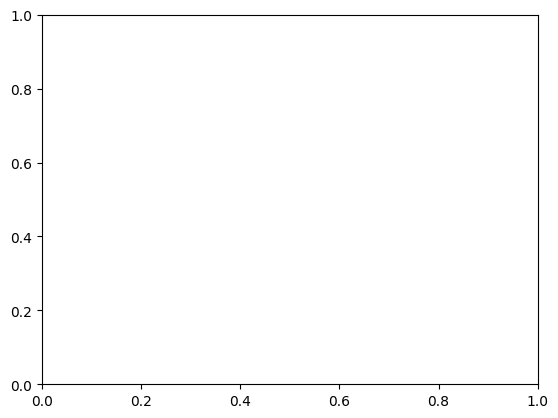

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation

fig, ax = plt.subplots()
def update(frame):
    ax.clear()

    tiempo = frame
    u_final = 0.5 * (u_t[tiempo, 0:n_puntos, 0:n_puntos] + u_t[tiempo, 1:n_puntos + 1, 0:n_puntos])
    v_final = 0.5 * (v_t[tiempo, 0:n_puntos, 0:n_puntos] + v_t[tiempo, 0:n_puntos, 1:n_puntos + 1])
    p_final = 0.25 * (p_t[tiempo, 0:n_puntos, 0:n_puntos] + p_t[tiempo, 0:n_puntos, 1:n_puntos + 1] +
                     p_t[tiempo, 1:n_puntos + 1, 0:n_puntos] + p_t[tiempo, 1:n_puntos + 1, 1:n_puntos + 1])

    x_dom = np.arange(0, n_puntos) * dx
    y_dom = 1 - np.arange(0, n_puntos) * dx
    X, Y = np.meshgrid(x_dom, y_dom)

    contour_plot = ax.contourf(X, Y, u_final, 21, cmap='jet', linewidths=0)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # Devolver una lista de artistas actualizados
    return [contour_plot]

# Establece el número total de frames (tiempos)
total_frames = n_tiempos

# Crea la animación
ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=50)

ani.save("movie.mp4")

ValueError: ignored

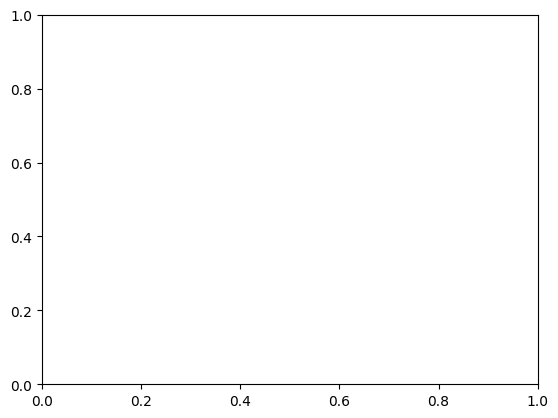

In [ ]:
x_dom = np.arange(0, n_puntos) * dx
y_dom = np.arange(0, n_puntos) * dx
X, Y = np.meshgrid(x_dom, y_dom)

fig, ax = plt.subplots()


ax.streamplot(X,Y,u_final,-v_final, density = 1)
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])
ax.set_title('Stream Plot of Field Lines')


plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
n_puntos=101
n_tiempos= 100

Lx=1
Ly=Lx
Lz=Lx

dx=Lx/(n_puntos-1)
dy=dx
dz=dx

x = np.arange(0, Lx + dx, dx)
y = np.arange(0, Ly + dy, dy)
z = np.arange(0, Lz + dz, dz)

Re=100
nu=1/Re
alpha=0.8
alpha_p=0.8
viento=2
error_req=1e-3
dt=0.5*dx*dy*dz

u_t=np.zeros((n_tiempos , n_puntos + 1 , n_puntos , n_puntos + 1))
v_t=np.zeros((n_tiempos , n_puntos , n_puntos + 1 , n_puntos + 1))
w_t=np.zeros((n_tiempos , n_puntos + 1 , n_puntos + 1 , n_puntos))
p_t=np.zeros((n_tiempos , n_puntos + 1 , n_puntos + 1 , n_puntos + 1))

u_final = np.zeros((n_puntos, n_puntos,n_puntos))
v_final = np.zeros((n_puntos, n_puntos,n_puntos))
w_final = np.zeros((n_puntos, n_puntos,n_puntos))
p_final = np.ones((n_puntos, n_puntos,n_puntos))
u_final[:,:,-1] = viento



u = np.zeros((n_puntos + 1, n_puntos, n_puntos + 1))
u_estrella = np.zeros((n_puntos + 1, n_puntos, n_puntos+1))
d_e = np.zeros((n_puntos + 1, n_puntos, n_puntos+1))
u[:,:,-1] = viento
u_estrella[:,:,-1] = viento


v = np.zeros((n_puntos, n_puntos + 1, n_puntos+1))
v_estrella = np.zeros((n_puntos, n_puntos + 1, n_puntos+1))
d_n = np.zeros((n_puntos, n_puntos + 1, n_puntos+1))

w = np.zeros((n_puntos+1,n_puntos+1,n_puntos))
w_estrella = np.zeros((n_puntos+1,n_puntos+1,n_puntos))
d_t = np.zeros((n_puntos+1,n_puntos+1,n_puntos))


p = np.ones((n_puntos + 1, n_puntos + 1,n_puntos + 1))
p_estrella = np.ones((n_puntos + 1, n_puntos + 1,n_puntos + 1))
pc = np.zeros((n_puntos + 1, n_puntos + 1,n_puntos + 1))
b = np.zeros((n_puntos + 1, n_puntos + 1,n_puntos + 1))

u_nuevo = np.zeros((n_puntos + 1, n_puntos,n_puntos+1))
v_nuevo = np.zeros((n_puntos, n_puntos + 1,n_puntos+1))
w_nuevo = np.zeros((n_puntos+1,n_puntos+1,n_puntos ))
p_nuevo = np.ones((n_puntos + 1, n_puntos + 1,n_puntos + 1))
u_nuevo[:,:, -1] = viento

error=1
iteraciones=0

u_t[0,:,:,:]=u
v_t[0,:,:,:]=v
w_t[0,:,:,:]=w
p_t[0,:,:,:]=p

for r in range(1,n_tiempos):
  u=u_t[r-1,:,:,:]
  v=v_t[r-1,:,:,:]
  w=w_t[r-1,:,:,:]
  p=p_t[r-1,:,:,:]
  while(error> error_req):
    errorV=1
    while (errorV > error_req):
      u_E=0.5*(u[1:n_puntos,1:n_puntos-1,1:n_puntos]+u[1:n_puntos,2:n_puntos,1:n_puntos])
      u_W=0.5*(u[1:n_puntos,1:n_puntos-1,1:n_puntos]+u[1:n_puntos,0:n_puntos-2,1:n_puntos])
      v_N=0.5*(v[0:n_puntos-1,1:n_puntos-1,1:n_puntos]+v[0:n_puntos-1,2:n_puntos,1:n_puntos])
      v_S=0.5*(v[1:n_puntos,1:n_puntos-1,1:n_puntos]+v[1:n_puntos,2:n_puntos,1:n_puntos])
      w_T = 0.5 * (w[1:n_puntos, 1:n_puntos-1, 1:n_puntos] + w[1:n_puntos, 2:n_puntos, 1:n_puntos])
      w_B = 0.5 * (w[1:n_puntos, 1:n_puntos-1, 0:n_puntos-1]   + w[1:n_puntos,2:n_puntos ,0:n_puntos-1])

      a_E = -0.5 * u_E * dx**2 + nu*dx
      a_W = 0.5 * u_W * dx**2 + nu*dx
      a_N = -0.5 * v_N * dx**2 + nu*dx
      a_S = 0.5 * v_S * dx**2 + nu*dx
      a_T = -0.5 * w_T * dx**2 + nu*dx
      a_B = 0.5 * w_B * dx**2 + nu*dx

      a_e0 = dx*dy*dz/dt
      a_e = 0.5 * u_E * (dx**2) - 0.5 * u_W * (dx**2) + 0.5 * v_N * (dx**2) - 0.5 * v_S * (dx**2) + 0.5 * w_T * (dx**2) - 0.5 * w_B * (dx**2) + 6 * nu*dx + a_e0

      A_e = -(dx**2)
      d_e[1:n_puntos,1:n_puntos-1,1:n_puntos] = A_e / a_e

      u_estrella[1:n_puntos,1:n_puntos-1,1:n_puntos] = ((a_E * u[1:n_puntos,2:n_puntos,1:n_puntos] + a_W * u[1:n_puntos,0:n_puntos-2,1:n_puntos] + a_N * u[0:n_puntos-1,1:n_puntos-1,1:n_puntos] + a_S * u[2:n_puntos+1,1:n_puntos-1,1:n_puntos] + a_T * u[1:n_puntos,1:n_puntos-1,2:n_puntos+1] + a_B * u[1:n_puntos,1:n_puntos-1,0:n_puntos-1] + a_e0*u[1:n_puntos,1:n_puntos-1,1:n_puntos]) / a_e + d_e[1:n_puntos,1:n_puntos-1,1:n_puntos] * (p[1:n_puntos,2:n_puntos,1:n_puntos] - p[1:n_puntos,1:n_puntos-1,1:n_puntos]))
      del u_E, u_W, v_N, v_S , w_T , w_B

      u_E = 0.5 * (u[1:n_puntos-1,1:n_puntos,1:n_puntos] + u[2:n_puntos,1:n_puntos,1:n_puntos])
      u_W = 0.5 * (u[1:n_puntos-1,0:n_puntos-1,1:n_puntos] + u[2:n_puntos,0:n_puntos-1,1:n_puntos])
      v_N = 0.5 * (v[0:n_puntos-2,1:n_puntos,1:n_puntos] + v[1:n_puntos-1,1:n_puntos,1:n_puntos])
      v_S = 0.5 * (v[1:n_puntos-1,1:n_puntos,1:n_puntos] + v[2:n_puntos,1:n_puntos,1:n_puntos])
      w_T = 0.5 * (w[1:n_puntos-1,1:n_puntos,1:n_puntos] + w[2:n_puntos,1:n_puntos,1:n_puntos])
      w_B = 0.5 * (w[1:n_puntos-1,1:n_puntos,0:n_puntos-1] + w[2:n_puntos,1:n_puntos,0:n_puntos-1])

      a_E = -0.5 * u_E * dx**2 + nu*dx
      a_W = 0.5 * u_W * dx**2 + nu*dx
      a_N = -0.5 * v_N * dx**2 + nu*dx
      a_S = 0.5 * v_S * dx**2 + nu*dx
      a_T = -0.5 * w_T * dx**2 + nu*dx
      a_B = 0.5 * w_B * dx**2 + nu*dx

      a_n0=dx*dy*dz/dt
      a_n = 0.5 * u_E * (dx**2) - 0.5 * u_W * (dx**2) + 0.5 * v_N * (dx**2) - 0.5 * v_S * (dx**2) + 0.5 * w_T * (dx**2) - 0.5 * w_B * (dx**2) + 6 * nu*dx + a_n0

      A_n = -(dx**2)
      d_n[1:n_puntos-1,1:n_puntos,1:n_puntos] = A_n / a_n

      v_estrella[1:n_puntos-1,1:n_puntos,1:n_puntos] = ((a_E * v[1:n_puntos-1,2:n_puntos+1,1:n_puntos] + a_W * v[1:n_puntos-1,0:n_puntos-1,1:n_puntos] + a_N * v[0:n_puntos-2,1:n_puntos,1:n_puntos] + a_S * v[2:n_puntos,1:n_puntos,1:n_puntos] + a_T * v[1:n_puntos-1,1:n_puntos,2:n_puntos+1] + a_B * v[1:n_puntos-1,1:n_puntos,0:n_puntos-1] + a_n0*v[1:n_puntos-1,1:n_puntos,1:n_puntos]) / a_n + d_n[1:n_puntos-1,1:n_puntos,1:n_puntos] * (p[1:n_puntos-1,1:n_puntos,1:n_puntos] - p[2:n_puntos,1:n_puntos,1:n_puntos]))

      del u_E, u_W, v_N, v_S, w_T , w_B

      u_E = 0.5 * (u[1:n_puntos,1:n_puntos,1:n_puntos-1] + u[1:n_puntos,1:n_puntos,2:n_puntos])
      u_W = 0.5 * (u[1:n_puntos,0:n_puntos-1,1:n_puntos-1] + u[1:n_puntos,0:n_puntos-1,2:n_puntos])
      v_N = 0.5 * (v[0:n_puntos-1,1:n_puntos,1:n_puntos-1] + v[0:n_puntos-1,1:n_puntos,2:n_puntos])
      v_S = 0.5 * (v[1:n_puntos,1:n_puntos,1:n_puntos-1] + v[1:n_puntos,1:n_puntos,2:n_puntos])
      w_T = 0.5 * (w[1:n_puntos,1:n_puntos,1:n_puntos-1] + w[1:n_puntos,1:n_puntos,2:n_puntos])
      w_B = 0.5 * (w[1:n_puntos,1:n_puntos,0:n_puntos-2] + w[1:n_puntos,1:n_puntos,1:n_puntos-1])


      a_E = -0.5 * u_E * dx**2 + nu*dx
      a_W = 0.5 * u_W * dx**2 + nu*dx
      a_N = -0.5 * v_N * dx**2 + nu*dx
      a_S = 0.5 * v_S * dx**2 + nu*dx
      a_T = -0.5 * w_T * dx**2 + nu*dx
      a_B = 0.5 * w_B * dx**2 + nu*dx

      a_t0=dx*dy*dz/dt
      a_t = 0.5 * u_E * (dx**2) - 0.5 * u_W * (dx**2) + 0.5 * v_N * (dx**2) - 0.5 * v_S * (dx**2) + 0.5 * w_T * (dx**2)-0.5 * w_B * (dx**2) + 6 * nu*dx + a_t0

      A_t = -(dx**2)
      d_t[1:n_puntos,1:n_puntos,1:n_puntos-1] = A_t / a_t

      w_estrella[1:n_puntos,1:n_puntos,1:n_puntos-1] = ((a_E * w[1:n_puntos,2:n_puntos+1,1:n_puntos-1] + a_W * w[1:n_puntos,0:n_puntos-1,1:n_puntos-1] + a_N * w[0:n_puntos-1,1:n_puntos,1:n_puntos-1] + a_S * w[2:n_puntos+1,1:n_puntos,1:n_puntos-1] + a_T * w[1:n_puntos,1:n_puntos,2:n_puntos] + a_B * w[1:n_puntos,1:n_puntos,0:n_puntos-2] + a_t0*w[1:n_puntos,1:n_puntos,1:n_puntos-1]) / a_t+ d_t[1:n_puntos,1:n_puntos,1:n_puntos-1] * (p[1:n_puntos,1:n_puntos,2:n_puntos] - p[1:n_puntos,1:n_puntos,1:n_puntos-1]))

      del u_E, u_W, v_N, v_S, w_T , w_B

      # Residual de continuidad como medida de error
      errorV = np.sum(np.abs(v_estrella - v))+np.sum(np.abs(u_estrella - u))+np.sum(np.abs(w_estrella - w))


      # Finalizar la iteración
      u = u_estrella
      v = v_estrella
      w = w_estrella

    pc = np.zeros((n_puntos + 1, n_puntos + 1,n_puntos+1))
    pc_aux = np.zeros((n_puntos + 1, n_puntos + 1, n_puntos + 1))
    errorP=1
    while (errorP > error_req):
      a_E = -d_e[1:n_puntos,1:n_puntos,1:n_puntos] * (dx**2)
      a_W = -d_e[1:n_puntos,0:n_puntos-1,1:n_puntos] * (dx**2)
      a_N = -d_n[0:n_puntos-1,1:n_puntos,1:n_puntos] * (dx**2)
      a_S = -d_n[1:n_puntos,1:n_puntos,1:n_puntos] * (dx**2)
      a_T = -d_t[1:n_puntos,1:n_puntos,1:n_puntos] * (dx**2)
      a_B = -d_t[1:n_puntos,1:n_puntos,0:n_puntos-1] * (dx**2)

      a_P = a_E + a_W + a_N + a_S + a_T + a_B
      b[1:n_puntos, 1:n_puntos , 1:n_puntos] = -(u_estrella[1:n_puntos,1:n_puntos,1:n_puntos] - u_estrella[1:n_puntos,0:n_puntos-1,1:n_puntos]) * (dx**2) + (v_estrella[1:n_puntos,1:n_puntos,1:n_puntos] - v_estrella[0:n_puntos-1,1:n_puntos,1:n_puntos]) * (dx**2) - (w_estrella[1:n_puntos,1:n_puntos,1:n_puntos] - w_estrella[1:n_puntos,1:n_puntos,0:n_puntos-1]) * (dx**2)

      pc_aux[1:n_puntos,1:n_puntos,1:n_puntos] = (a_E * pc[1:n_puntos,2:n_puntos+1,1:n_puntos] + a_W * pc[1:n_puntos,0:n_puntos-1,1:n_puntos] + a_N * pc[0:n_puntos-1,1:n_puntos,1:n_puntos] + a_S*pc[2:n_puntos+1,1:n_puntos,1:n_puntos] + a_T * pc[1:n_puntos,1:n_puntos,2:n_puntos+1] + a_B * pc[1:n_puntos,1:n_puntos,0:n_puntos-1] + b[1:n_puntos,1:n_puntos,1:n_puntos])/a_P

      del a_E, a_W, a_N, a_S, a_T, a_B ,a_P
      # Monitoreo del error después de cada pocos pasos de tiempo
      errorP=np.sum(np.abs(pc-pc_aux))
      pc=pc_aux

    p_nuevo = p + alpha_p * pc

    p_nuevo[0,:,:]=p_nuevo[1,:,:]
    p_nuevo[n_puntos,:,:]=p_nuevo[n_puntos-1,:,:]

    p_nuevo[:,0,:]=p_nuevo[:,1,:]
    p_nuevo[:,n_puntos,:]=p_nuevo[:,n_puntos-1,:]

    p_nuevo[:,:,0]=p_nuevo[:,:,1]
    p_nuevo[:,:,n_puntos]=p_nuevo[:,:,n_puntos-1]

    u_nuevo[1:n_puntos,1:n_puntos-1,1:n_puntos] = u_estrella[1:n_puntos,1:n_puntos-1,1:n_puntos] + alpha * d_e[1:n_puntos,1:n_puntos-1,1:n_puntos] * (pc[1:n_puntos,2:n_puntos,1:n_puntos] - pc[1:n_puntos,1:n_puntos-1,1:n_puntos])
    v_nuevo[1:n_puntos-1,1:n_puntos,1:n_puntos] = v_estrella[1:n_puntos-1,1:n_puntos,1:n_puntos] + alpha * d_n[1:n_puntos-1,1:n_puntos,1:n_puntos] * (pc[1:n_puntos-1,1:n_puntos,1:n_puntos] - pc[2:n_puntos,1:n_puntos,1:n_puntos])
    w_nuevo[1:n_puntos,1:n_puntos,1:n_puntos-1] = w_estrella[1:n_puntos,1:n_puntos,1:n_puntos-1] + alpha * d_t[1:n_puntos,1:n_puntos,1:n_puntos-1] * (pc[1:n_puntos,1:n_puntos,2:n_puntos] - pc[1:n_puntos,1:n_puntos,1:n_puntos-1])


    # Residual de continuidad como medida de error
    error = np.sum(np.abs(b[1:-1, 1:-1, 1:-1]))
    # Monitoreo del error después de cada pocos pasos de tiempo
    if iteraciones % 100 == 0:
        print("error campo =" + str(error))
    u = u_nuevo
    v = v_nuevo
    w = w_nuevo
    p = p_nuevo
    iteraciones += 1
  error=1
  u_t[r,:,:,:]=u
  v_t[r,:,:,:]=v
  w_t[r,:,:,:]=w
  p_t[r,:,:,:]=p

error campo =3.9986984210645e-06


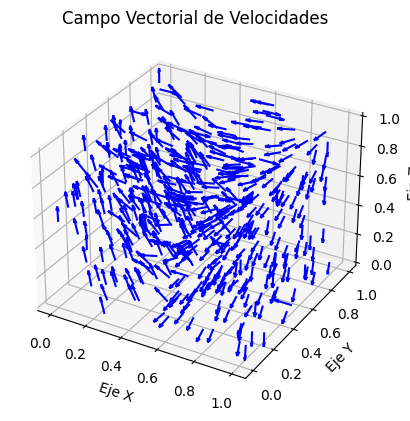

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

tiempo= n_tiempos-1
u_final = np.zeros((n_puntos, n_puntos, n_puntos))
v_final = np.zeros((n_puntos, n_puntos, n_puntos))
w_final = np.zeros((n_puntos, n_puntos, n_puntos))

u_final = 0.25 * (u_t[tiempo, 1:n_puntos+1, 0:n_puntos, 1:n_puntos+1] + u_t[tiempo, 1:n_puntos+1,0:n_puntos,0:n_puntos] + u_t[tiempo,0:n_puntos,0:n_puntos,1:n_puntos+1] + u_t[tiempo,0:n_puntos,0:n_puntos,0:n_puntos])
v_final = 0.25 * (v_t[tiempo, 0:n_puntos,1:n_puntos+1,1:n_puntos+1] + v_t[tiempo,0:n_puntos,1:n_puntos+1,0:n_puntos] + v_t[tiempo,0:n_puntos,0:n_puntos,1:n_puntos+1] + v_t[tiempo,0:n_puntos,0:n_puntos,0:n_puntos])
w_final = 0.25 * (w_t[tiempo, 1:n_puntos+1,1:n_puntos+1,0:n_puntos] + w_t[tiempo,1:n_puntos+1,0:n_puntos,0:n_puntos] + w_t[tiempo,0:n_puntos,1:n_puntos+1,0:n_puntos] + w_t[tiempo,0:n_puntos,0:n_puntos,0:n_puntos])

X,Y,Z = np.meshgrid(x,y,z)

indices = np.random.choice(np.arange(X.size), 512, replace=False)

selected_X = X.flatten()[indices]
selected_Y = Y.flatten()[indices]
selected_Z = Z.flatten()[indices]
selected_u = u_final.flatten()[indices]
selected_v = v_final.flatten()[indices]
selected_w = w_final.flatten()[indices]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.quiver(selected_X, selected_Y, selected_Z, selected_u, selected_v, selected_w,length=0.1, normalize=True, color='b')

ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
ax.set_title('Campo Vectorial de Velocidades')

# Muestra la gráfica
plt.show()

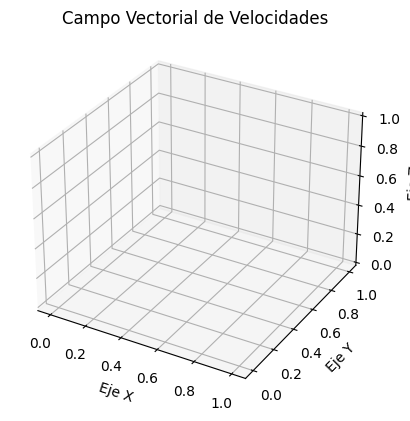

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

n_puntos = 101

# Supongamos que tienes tus matrices u, v, w definidas aquí

# Inicializa las matrices u_final, v_final, w_final según tu lógica
u_final = np.zeros((n_puntos, n_puntos, n_puntos))
v_final = np.zeros((n_puntos, n_puntos, n_puntos))
w_final = np.zeros((n_puntos, n_puntos, n_puntos))

# Calcula los valores en u_final, v_final, w_final según tu lógica
# ...

# Definir la malla
x = np.linspace(0, 1, n_puntos)
y = np.linspace(0, 1, n_puntos)
z = np.linspace(0, 1, n_puntos)

X, Y, Z = np.meshgrid(x, y, z)

# Seleccionar conjuntos específicos de índices en Z
z_indices = np.arange(0, n_puntos, 10)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Número máximo de puntos por plano XY
max_points_per_plane = 5

for z_index in z_indices:
    indices = np.where(Z == z[z_index])
    selected_indices = np.random.choice(len(indices[0]), max_points_per_plane, replace=False)

    selected_X = X[indices][selected_indices]
    selected_Y = Y[indices][selected_indices]
    selected_Z = Z[indices][selected_indices]
    selected_u = u_final[indices][selected_indices]
    selected_v = v_final[indices][selected_indices]
    selected_w = w_final[indices][selected_indices]

    ax.quiver(selected_X, selected_Y, selected_Z, selected_u, selected_v, selected_w,
              length=0.1, normalize=True, color='b')

ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
ax.set_title('Campo Vectorial de Velocidades')

# Muestra la gráfica
plt.show()


In [ ]:
indices

array([81988, 78475, 19288, 25104, 56198])

<ipython-input-5-f1728eeff37f>:7: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(X[:,:,0], Y[:,:,0], u_final[:,:,0], 21, cmap='jet', linewidths=0)
<ipython-input-5-f1728eeff37f>:14: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(X[:,:,-1], Y[:,:,-1], u_final[:,:,-1], 21, cmap='jet', linewidths=0)
<ipython-input-5-f1728eeff37f>:21: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(X[0,:,:], Z[0,:,:], w_final[0,:,:], 21, cmap='jet', linewidths=0)
<ipython-input-5-f1728eeff37f>:28: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(X[-1,:,:], Z[-1,:,:], w_final[-1,:,:], 21, cmap='jet', linewidths=0)
<ipython-input-5-f1728eeff37f>:35: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(Y[:,0,:], Z[:,0,:], v_final[:,0,:], 21, cmap='jet', linewidths=0)
<ipython-input-5-f1728eeff37f>:42: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.co

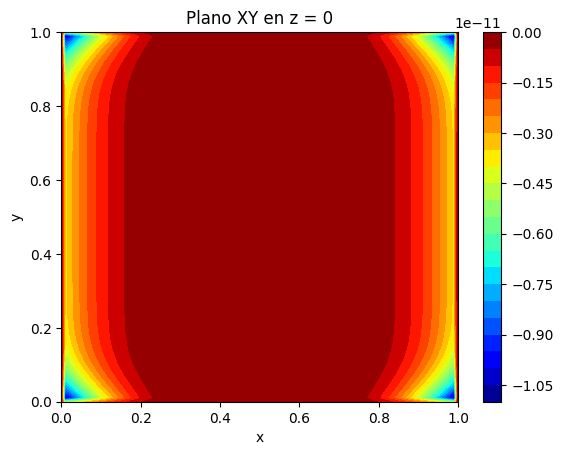

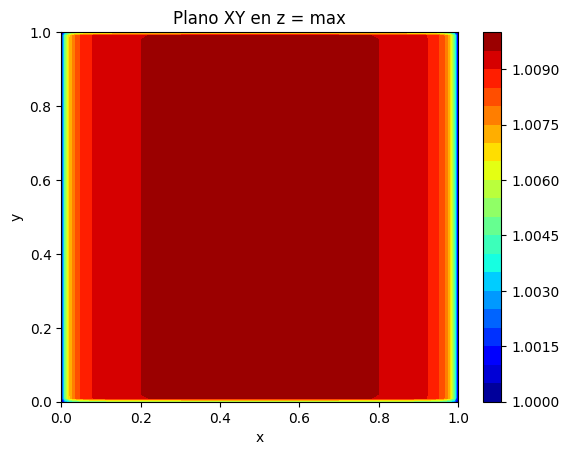

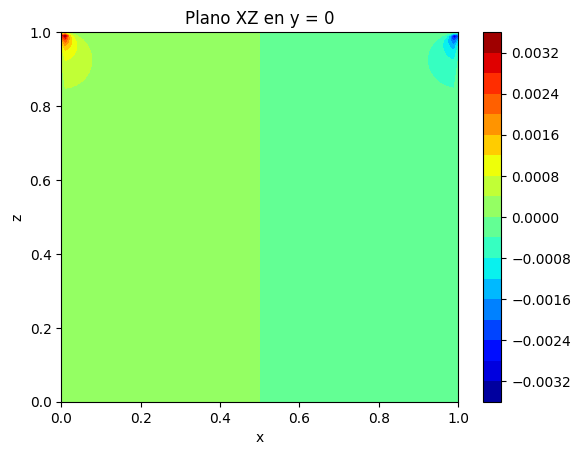

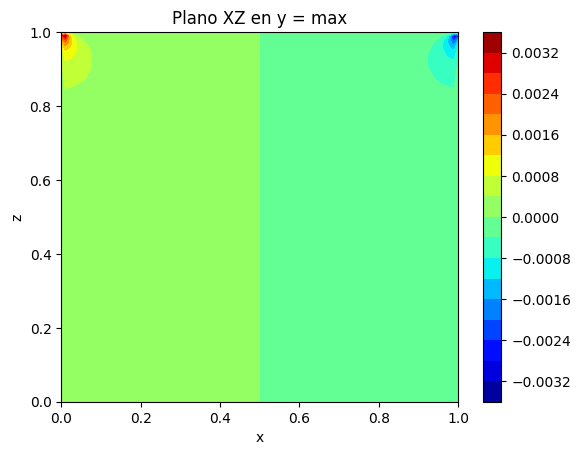

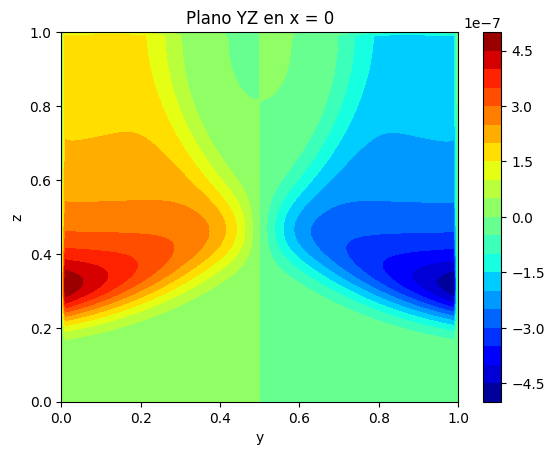

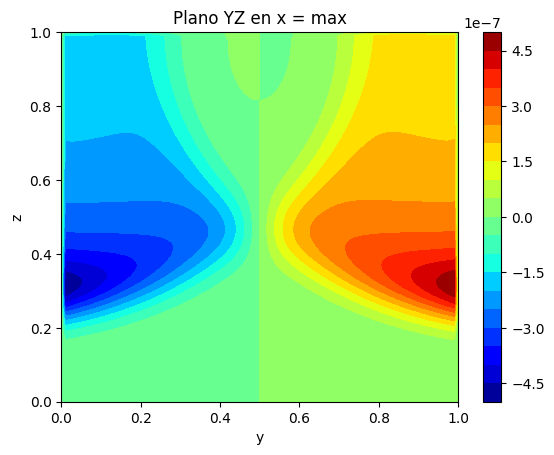

<ipython-input-5-f1728eeff37f>:50: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(X[0,:,:], Z[0,:,:], u_final[0,:,:], 21, cmap='jet', linewidths=0)


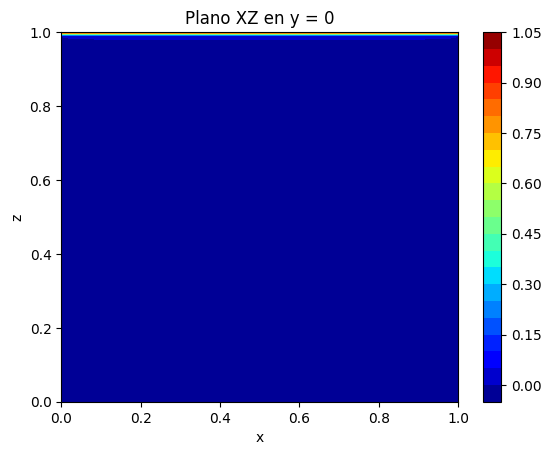

<ipython-input-5-f1728eeff37f>:58: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(X[-1,:,:], Z[-1,:,:], u_final[-1,:,:], 21, cmap='jet', linewidths=0)


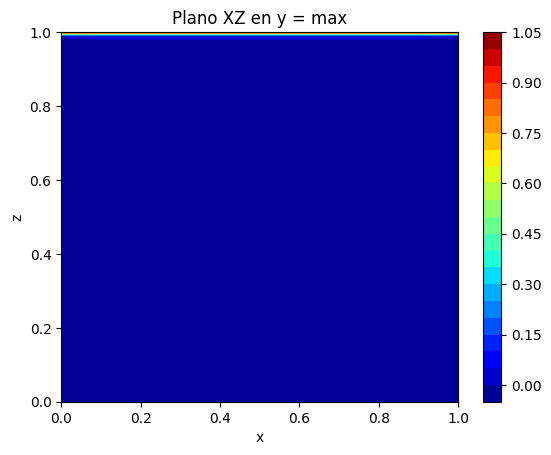

<ipython-input-5-f1728eeff37f>:66: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(Y[:,0,:], Z[:,0,:], u_final[:,0,:], 21, cmap='jet', linewidths=0)


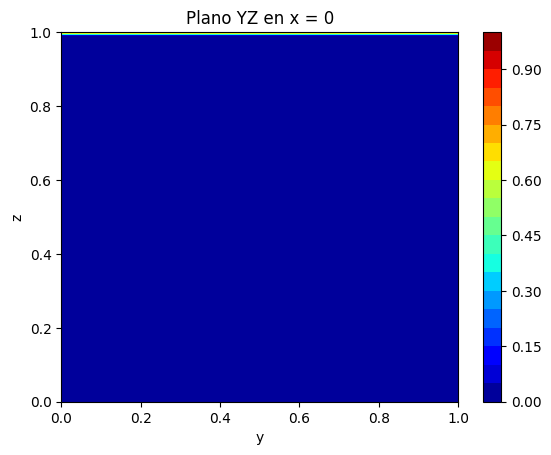

<ipython-input-5-f1728eeff37f>:74: UserWarning: linewidths is ignored by contourf
  contour_plot = plt.contourf(Y[:,-1,:], Z[:,-1,:], u_final[:,-1,:], 21, cmap='jet', linewidths=0)


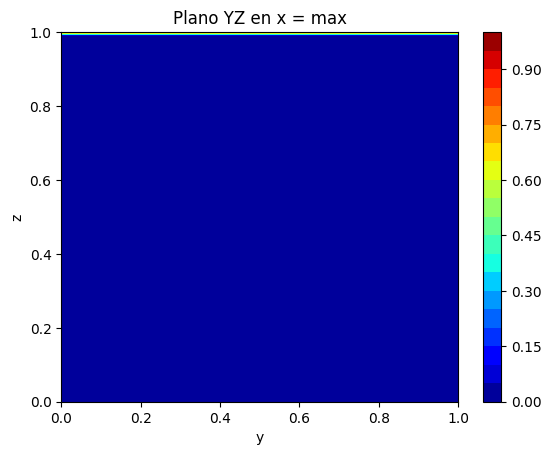

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import axes3d
n_puntos=101

plt.figure(21)
contour_plot = plt.contourf(X[:,:,0], Y[:,:,0], u_final[:,:,0], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plano XY en z = 0')

plt.figure(22)
contour_plot = plt.contourf(X[:,:,-1], Y[:,:,-1], u_final[:,:,-1], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plano XY en z = max')

plt.figure(23)
contour_plot = plt.contourf(X[0,:,:], Z[0,:,:], w_final[0,:,:], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('x')
plt.ylabel('z')
plt.title('Plano XZ en y = 0')

plt.figure(24)
contour_plot = plt.contourf(X[-1,:,:], Z[-1,:,:], w_final[-1,:,:], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('x')
plt.ylabel('z')
plt.title('Plano XZ en y = max')

plt.figure(25)
contour_plot = plt.contourf(Y[:,0,:], Z[:,0,:], v_final[:,0,:], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('y')
plt.ylabel('z')
plt.title('Plano YZ en x = 0')

plt.figure(26)
contour_plot = plt.contourf(Y[:,-1,:], Z[:,-1,:], v_final[:,-1,:], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('y')
plt.ylabel('z')
plt.title('Plano YZ en x = max')
plt.show()

plt.figure(27)
contour_plot = plt.contourf(X[0,:,:], Z[0,:,:], u_final[0,:,:], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('x')
plt.ylabel('z')
plt.title('Plano XZ en y = 0')
plt.show()

plt.figure(28)
contour_plot = plt.contourf(X[-1,:,:], Z[-1,:,:], u_final[-1,:,:], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('x')
plt.ylabel('z')
plt.title('Plano XZ en y = max')
plt.show()

plt.figure(29)
contour_plot = plt.contourf(Y[:,0,:], Z[:,0,:], u_final[:,0,:], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('y')
plt.ylabel('z')
plt.title('Plano YZ en x = 0')
plt.show()

plt.figure(30)
contour_plot = plt.contourf(Y[:,-1,:], Z[:,-1,:], u_final[:,-1,:], 21, cmap='jet', linewidths=0)
plt.colorbar(contour_plot)
plt.xlabel('y')
plt.ylabel('z')
plt.title('Plano YZ en x = max')
plt.show()

plt.show()






ValueError: ignored

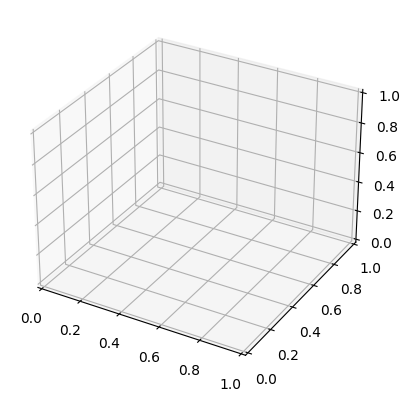

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define tus datos o utiliza los que ya tienes
n_puntos = 10
dx = 1.0
x_dom = np.arange(0, n_puntos) * dx
y_dom = np.arange(0, n_puntos) * dx
z_dom = np.arange(0, n_puntos) * dx

X, Y, Z = np.meshgrid(x_dom, y_dom, z_dom)

# Supongamos que tienes datos para u_final, v_final, w_final
u_final = np.sin(X)
v_final = np.cos(Y)
w_final = np.exp(-Z)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Selecciona solo algunos puntos para las líneas de flujo
start_points = np.column_stack((X[:,:,0].flatten(), Y[:,:,0].flatten(), Z[:,:,0].flatten()))

# Crea las líneas de flujo en el plano XY
streamlines = ax.streamplot(X[:,:,0], Y[:,:,0], u_final[:,:,0], v_final[:,:,0], start_points=start_points, color='blue', arrowstyle='->', arrowsize=1.5, linewidth=1.5)

# Ajusta la altura de las líneas en función de la componente Z del campo vectorial
for line in streamlines.lines:
    line.set_3d_properties(Z[:,:,0].flatten(), 'z')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Stream Plot in 3D')

plt.show()


IndexError: ignored

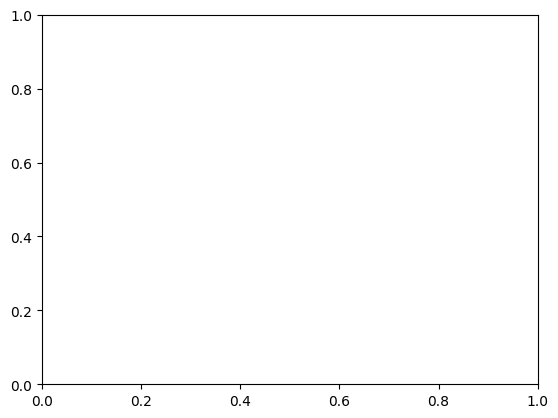

In [ ]:
x_dom = np.arange(0, n_puntos) * dx
y_dom = np.arange(0, n_puntos) * dx
X, Y = np.meshgrid(x_dom, y_dom)

fig, ax = plt.subplots()


ax.streamplot(X[:,:,0],Y[:,:,0],u_final[:,:,0],-v_final[:,:,0], density = 1)
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])
ax.set_title('Stream Plot of Field Lines')


plt.show()

In [ ]:
x_dom = np.arange(0, n_puntos) * dx
y_dom = np.arange(0, n_puntos) * dx
X, Y = np.meshgrid(x_dom, y_dom)

fig, ax = plt.subplots()


ax.streamplot(X,Y,u_final,-v_final, density = 1)
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])
ax.set_title('Stream Plot of Field Lines')


plt.show()

In [ ]:
!pip install getfem


ERROR: Could not find a version that satisfies the requirement getfem (from versions: none)
ERROR: No matching distribution found for getfem


In [ ]:
import getfem as gf
import numpy as np

ModuleNotFoundError: No module named 'getfem'